In [1]:
import subprocess
import sys

def install_if_missing(package):
    """Check if package is installed, if not install it."""
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Install packages
install_if_missing('pandas')
install_if_missing('numpy')
install_if_missing('matplotlib')
install_if_missing('pylab')
install_if_missing('IPython')

# Now import them
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

import time
import math

import pylab as py
from IPython.display import HTML

In [2]:
class Body:
    def __init__(self, mass, position, velocity):
        self.mass = mass
        self.position = position
        self.velocity = velocity

    def copy(self):
        return Body(self.mass, self.position[:], self.velocity[:])

In [3]:
#parameters
G = 6.673e-11 #N m^2 / kg^2

M_Earth  = 6.0e24
M_oculus = 500 #kg
M_lux = 500 #kg

R_earth = 6371e3 #m
R_orbit = 100e6 #m

d_spacecraft = 140 #m

orbit_inclination = 51.6 * math.pi / 180 # radians

orientation_polar = 90 * math.pi / 180 # radians
orientation_azimuthal = 0 * math.pi / 180 # radians

N_steps = 50000

v_spacecraft_0 = math.sqrt(G*M_Earth/R_orbit) # m/s

In [4]:
r_oculus_0 = np.array([R_orbit*np.cos(orbit_inclination), 0, R_orbit*np.sin(orbit_inclination)])
v_oculus_0 = np.array([0, v_spacecraft_0, 0])

r_lux_0 = r_oculus_0 + np.array([d_spacecraft*np.cos(orientation_polar)*math.cos(orientation_azimuthal), d_spacecraft*np.cos(orientation_polar)*math.sin(orientation_azimuthal), d_spacecraft*np.sin(orientation_polar)])
v_lux_0 = v_oculus_0 + np.array([0, 0, 0]) # Assuming same velocity for simplicity

orbital_normal_vector = np.array([-np.sin(orbit_inclination), 0, np.cos(orbit_inclination)]) # Assuming normal vector along z-axis for simplicity

In [5]:
T_orbit = 2*math.pi*R_orbit/v_spacecraft_0
T_orbit_hours = T_orbit / 3600
T_orbit_days = T_orbit_hours / 24
dt = T_orbit / N_steps
t = np.linspace(0, T_orbit, N_steps)

In [6]:
print(f"Orbital period: {T_orbit:.2f} seconds")
print(f"Orbital period: {T_orbit_hours:.2f} hours")

Orbital period: 314010.15 seconds
Orbital period: 87.23 hours


In [7]:
def compute_gravitational_acceleration(position):
    r = np.linalg.norm(position)
    return -G * M_Earth / r**3 * position

def update_position_velocity(body, dt):
    # Compute acceleration
    acceleration = compute_gravitational_acceleration(body.position)
    
    # Update velocity (using simple Euler method)
    body.velocity += acceleration * dt
    
    # Update position
    body.position += body.velocity * dt

In [8]:
r_oculus = np.zeros((N_steps, 3))
v_oculus = np.zeros((N_steps, 3))
r_lux = np.zeros((N_steps, 3))
v_lux = np.zeros((N_steps, 3))
r_oculus[0] = r_oculus_0
v_oculus[0] = v_oculus_0
r_lux[0] = r_lux_0
v_lux[0] = v_lux_0
oculus = Body(M_oculus, r_oculus_0, v_oculus_0)
lux = Body(M_lux, r_lux_0, v_lux_0)

dv_lux = np.zeros((N_steps, 3))
a_lux = np.zeros((N_steps, 3))
F_lux = np.zeros((N_steps, 3))
F_lux_grav = np.zeros((N_steps, 3))
F_lux_constraint = np.zeros((N_steps, 3))


dv_oculus = np.zeros((N_steps, 3))
a_oculus = np.zeros((N_steps, 3))
F_oculus = np.zeros((N_steps, 3))
F_oculus_grav = np.zeros((N_steps, 3))
F_oculus_constraint = np.zeros((N_steps, 3))

Total_impulse_lux = 0

for i in range(1, N_steps):
    # Euler step for the oculus body
    r = oculus.position
    v = oculus.velocity

    r = r + v * dt
    a = compute_gravitational_acceleration(r)
    v = v + a * dt

    oculus.position = r
    oculus.velocity = v

    # lux remains fixed relative to oculus
    lux.position = oculus.position + (r_lux_0 - r_oculus_0) # Maintain initial relative position
    lux.velocity = oculus.velocity

    r_oculus[i] = oculus.position
    v_oculus[i] = oculus.velocity
    r_lux[i] = lux.position
    v_lux[i] = lux.velocity

    dv_oculus[i] = v_oculus[i] - v_oculus[i-1]
    a_oculus[i] = dv_oculus[i] / dt
    F_oculus[i] = oculus.mass * a_oculus[i]
    F_oculus_grav[i] = compute_gravitational_acceleration(r_oculus[i]) * oculus.mass
    F_oculus_constraint[i] = F_oculus[i] - F_oculus_grav[i]

    dv_lux[i] = v_lux[i] - v_lux[i-1]
    a_lux[i] = dv_lux[i] / dt
    F_lux[i] = lux.mass * a_lux[i]
    F_lux_grav[i] = compute_gravitational_acceleration(r_lux[i]) * lux.mass
    F_lux_constraint[i] = F_lux[i] - F_lux_grav[i]
    Total_impulse_lux += np.linalg.norm(F_lux_constraint[i]) * dt

In [9]:
# drop the first entry from each of the position, velocity and force history arrays
r_oculus = r_oculus[4:]
r_lux    = r_lux[4:]
v_oculus = v_oculus[4:]
v_lux    = v_lux[4:]

F_oculus           = F_oculus[4:]
F_lux              = F_lux[4:]
F_lux_grav         = F_lux_grav[4:]
F_lux_constraint   = F_lux_constraint[4:]

t_plot = t[4:]
F_oculus_constraint = F_oculus_constraint[4:]

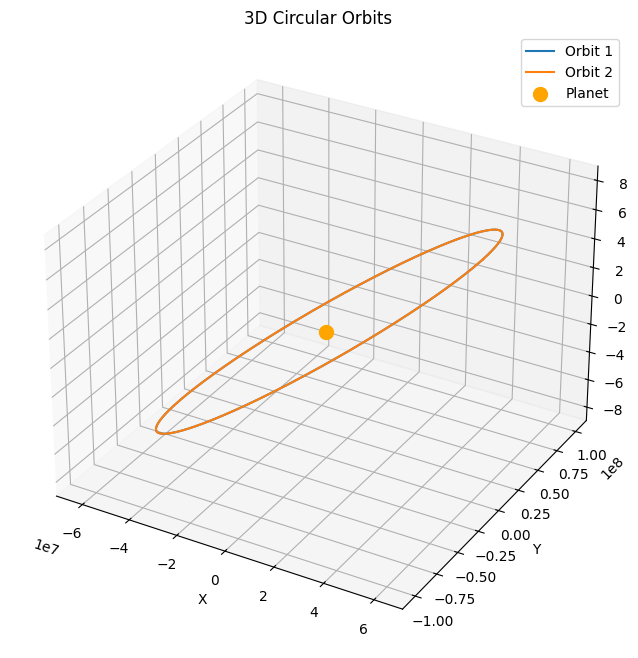

In [10]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(r_oculus[:, 0], r_oculus[:, 1], r_oculus[:, 2], label='Orbit 1')
ax.plot(r_lux[:, 0], r_lux[:, 1], r_lux[:, 2], label='Orbit 2')

# Central body
ax.scatter(0, 0, 0, color='orange', s=100, label='Planet')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Circular Orbits')
ax.legend()

plt.show()

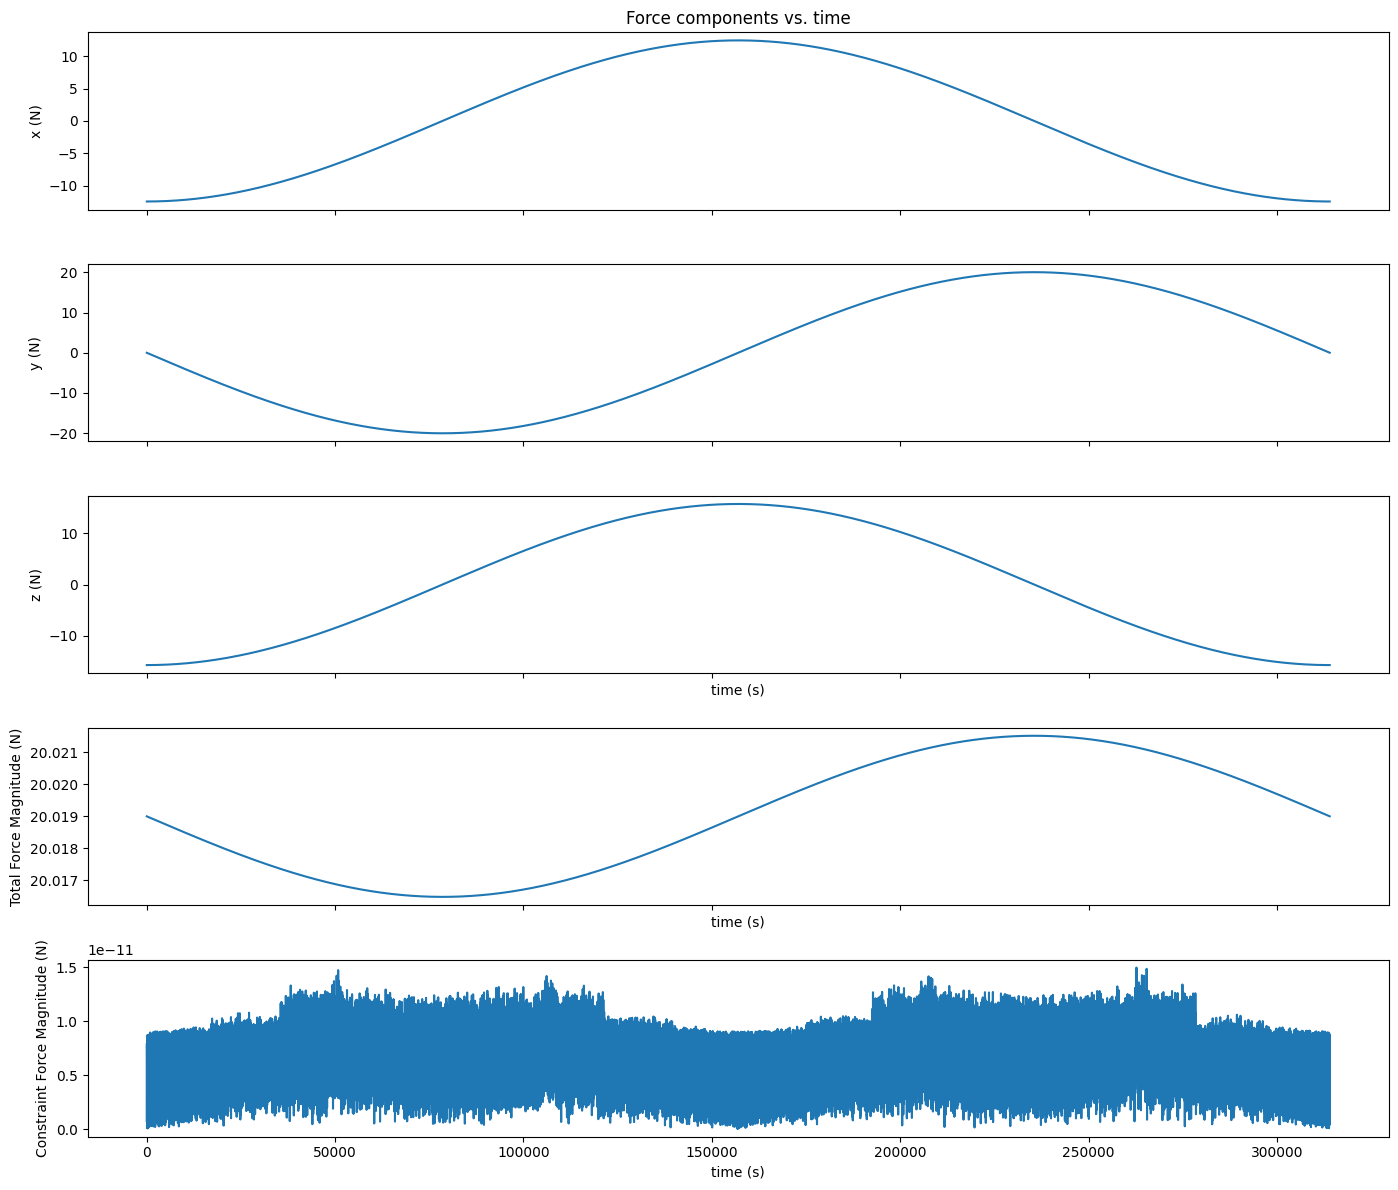

In [11]:
fig, axs = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

axs[0].plot(t_plot, F_oculus[:, 0])
axs[0].set_ylabel('x (N)')  
axs[0].set_title('Force components vs. time')

axs[1].plot(t_plot, F_oculus[:, 1])
axs[1].set_ylabel('y (N)')

axs[2].plot(t_plot, F_oculus[:, 2])
axs[2].set_ylabel('z (N)')
axs[2].set_xlabel('time (s)')

axs[3].plot(t_plot, np.linalg.norm(F_oculus, axis=1), label='Oculus')
axs[3].set_ylabel('Total Force Magnitude (N)')
axs[3].set_xlabel('time (s)')
#axs[3].set_ylim(0, np.max(np.linalg.norm(F_oculus, axis=1))*1.1)

axs[4].plot(t_plot, np.linalg.norm(F_oculus_constraint, axis=1), label='Oculus Constraint Force')
axs[4].set_ylabel('Constraint Force Magnitude (N)')
axs[4].set_xlabel('time (s)')

plt.tight_layout()
plt.show()

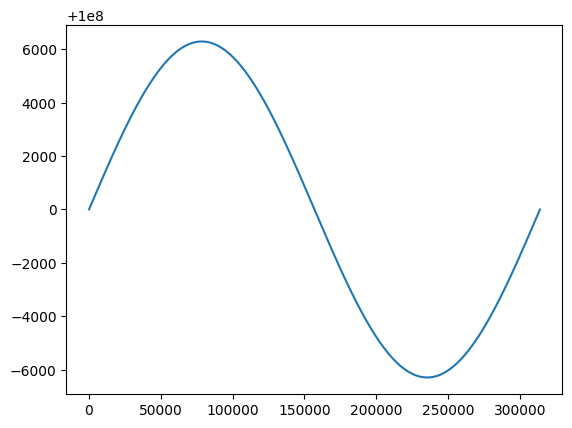

In [12]:
plt.plot(t_plot, np.linalg.norm(r_oculus, axis=1), label='Oculus')


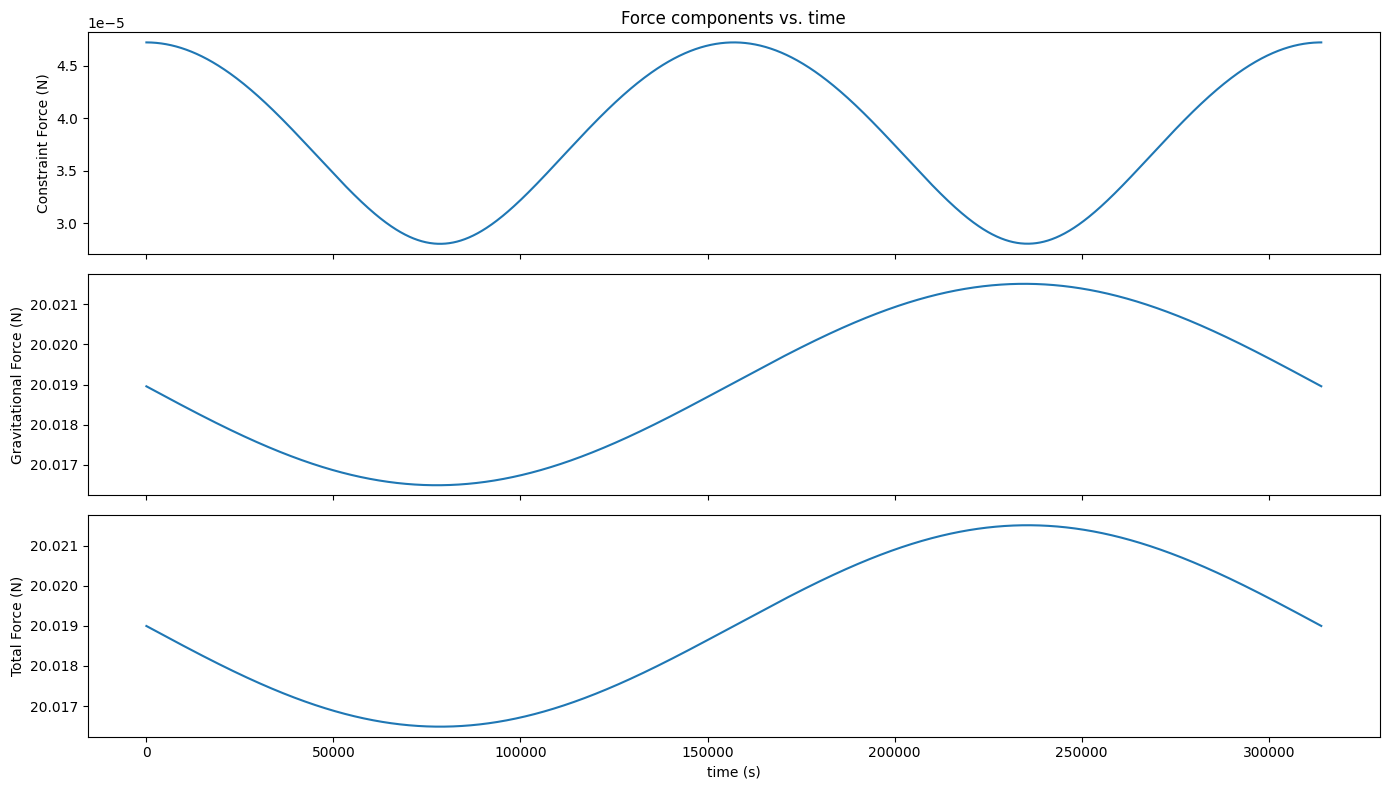

In [13]:
fig, axs = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axs[0].plot(t_plot, np.linalg.norm(F_lux_constraint, axis=1), label='F_lux_constraint_magnitude')
axs[0].set_ylabel('Constraint Force (N)')  
axs[0].set_title('Force components vs. time')


axs[1].plot(t_plot, np.linalg.norm(F_lux_grav, axis=1), label='F_lux_grav_magnitude')
axs[1].set_ylabel('Gravitational Force (N)')

axs[2].plot(t_plot, np.linalg.norm(F_lux, axis=1), label='F_lux_magnitude')
axs[2].set_ylabel('Total Force (N)')
axs[2].set_xlabel('time (s)')
#axs[2].set_ylim(0, np.max(np.linalg.norm(F_lux, axis=1))*1.1)


plt.tight_layout()
plt.show()

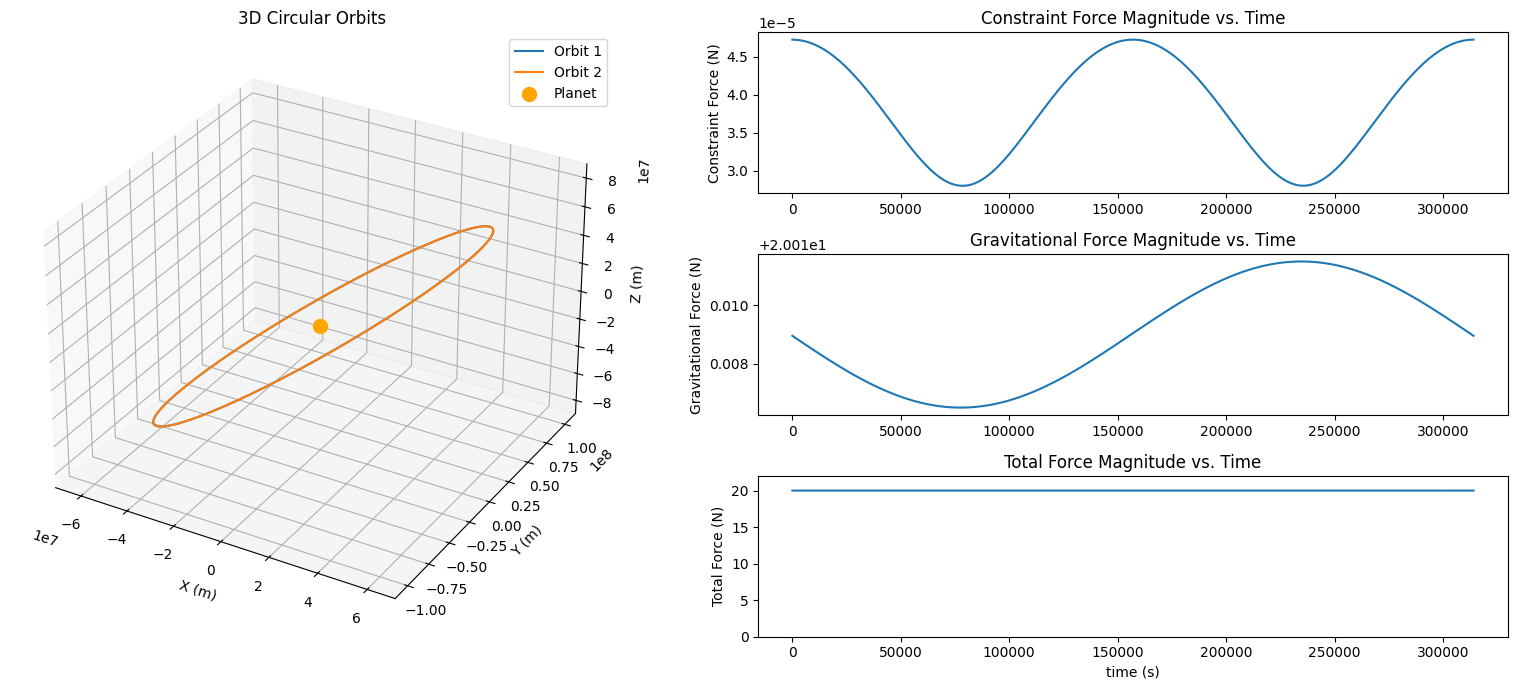

Total impulse applied to Lux in one orbit: 12.01 N*s
Total impulse applied to Lux in one year: 1207.23 N*s


In [14]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(3, 2, figure=fig)

# Left column: 3D orbit plot spanning all 3 rows
ax_left = fig.add_subplot(gs[:, 0], projection='3d')
ax_left.plot(r_oculus[:, 0], r_oculus[:, 1], r_oculus[:, 2], label='Orbit 1')
ax_left.plot(r_lux[:, 0], r_lux[:, 1], r_lux[:, 2], label='Orbit 2')
ax_left.scatter(0, 0, 0, color='orange', s=100, label='Planet')
ax_left.set_xlabel('X (m)')
ax_left.set_ylabel('Y (m)')
ax_left.set_zlabel('Z (m)')
ax_left.set_title('3D Circular Orbits')
ax_left.legend()

# Right column: three separate plots
ax_right1 = fig.add_subplot(gs[0, 1])
ax_right1.plot(t_plot, np.linalg.norm(F_lux_constraint, axis=1), label='F_lux_constraint_magnitude')
ax_right1.set_ylabel('Constraint Force (N)')
ax_right1.set_title('Constraint Force Magnitude vs. Time')

ax_right2 = fig.add_subplot(gs[1, 1])
ax_right2.plot(t_plot, np.linalg.norm(F_lux_grav, axis=1), label='F_lux_grav_magnitude')
ax_right2.set_ylabel('Gravitational Force (N)')
ax_right2.set_title('Gravitational Force Magnitude vs. Time')

ax_right3 = fig.add_subplot(gs[2, 1])
ax_right3.plot(t_plot, np.linalg.norm(F_lux, axis=1), label='F_lux_magnitude')
ax_right3.set_ylabel('Total Force (N)')
ax_right3.set_xlabel('time (s)')
ax_right3.set_title('Total Force Magnitude vs. Time')
ax_right3.set_ylim(0, np.max(np.linalg.norm(F_lux, axis=1))*1.1)

plt.tight_layout()
plt.show()
print(f"Total impulse applied to Lux in one orbit: {Total_impulse_lux:.2f} N*s")
print(f"Total impulse applied to Lux in one year: {Total_impulse_lux * (365.25 / T_orbit_days):.2f} N*s")